# scikit-learn Tutorial — Thesis-Focused
**Preparation Phase · Bachelor's Thesis: Benchmarking Tabular Data Augmentation Techniques for Deep Clustering**

Background: numpy ✓ · pandas ✓ · matplotlib ✓ · scikit-learn ← you are here

All sklearn estimators follow the same pattern: `.fit()` learns from data, `.transform()` applies what was learned.
Learn the pattern once — it works for every class in this notebook.

| § | Topic | Where you will use it |
|---|-------|-----------------------|
| 1 | `StandardScaler` | Scale numerical features before the encoder |
| 2 | `OneHotEncoder` | Encode categorical features as binary vectors |
| 3 | `ColumnTransformer` | Apply scaler and encoder to the right columns |
| 4 | `Pipeline` | Chain preprocessing + model into one object |
| 5 | `KMeans` | Cluster embeddings after the encoder |
| 6 | `PCA` | Reduce dimensions for visualisation and clustering |
| 7 | Metrics | NMI, ARI, Silhouette — evaluate clustering quality |
| 8 | `fetch_openml` | Load thesis datasets from OpenML |
| ★ | **Capstone** | Full pipeline: scale → PCA → KMeans → metrics → plot → PDF |

**Structure of each section:** explanation → worked example → mini-example → exercise → solution.

---
## Before You Run Anything: Understanding the Shared Data

### Two datasets used throughout this notebook

**Digits dataset** (`X_raw`, `y_true`) — 1 797 images of handwritten digits 0–9.
Each image is a flattened 8×8 grid of pixel intensities → 64 numerical features.
This is the exact dataset from your prep plan exercise and is structurally identical to
the OpenML datasets you will use in the thesis.

**Mixed DataFrame** (`df_mixed`) — 8 rows with 3 numerical columns and 1 categorical column.
Kept small so you can read every value and verify the ColumnTransformer output by eye.

### Variable guide

| Variable | Shape / type | What it represents |
|----------|--------------|--------------------|
| `X_raw` | (1797, 64) | Raw pixel values — not yet scaled |
| `y_true` | (1797,) | True digit label 0–9 — used **only** for NMI/ARI, never for training |
| `X_train` / `X_test` | (1437, 64) / (360, 64) | 80/20 split of `X_raw` |
| `y_train` / `y_test` | (1437,) / (360,) | Corresponding labels |
| `df_mixed` | (8, 4) DataFrame | Numerical + categorical columns for §2–§4 |

### Thesis pipeline reminder
```
CSV → pandas (you know this) → ColumnTransformer → numpy array → MLP encoder (PyTorch) → KMeans → NMI/ARI
                                     ↑ this notebook covers everything in this box ↑
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    silhouette_score,
)

# ── DIGITS DATASET ─────────────────────────────────────────────────────────
# 1797 handwritten digit images, each flattened to 64 pixel values.
digits = load_digits()
X_raw   = digits.data    # (1797, 64): 1797 samples × 64 features
y_true  = digits.target  # (1797,):   true digit label 0–9 (for NMI/ARI only)

# 80/20 train/test split — random_state=42 ensures the same split every run
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_true, test_size=0.2, random_state=42
)

# ── MIXED DATAFRAME ─────────────────────────────────────────────────────────
# Simulates a real tabular dataset: 3 numerical + 1 categorical column.
rng = np.random.default_rng(42)
n = 8
df_mixed = pd.DataFrame({
    'Age':       rng.integers(22, 55, size=n).astype(float),
    'Income':    rng.integers(30, 100, size=n).astype(float),
    'YearsExp':  rng.integers(0, 15, size=n).astype(float),
    'Education': rng.choice(['BSc', 'MSc', 'PhD'], size=n),
})

# ── COLOUR PALETTE (reused in §6 and Capstone) ──────────────────────────────
# 10 distinct colours — one per digit / cluster
COLORS_10 = [
    '#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
    '#a65628', '#f781bf', '#999999', '#66c2a5', '#fc8d62',
]

print('X_raw shape:   ', X_raw.shape,   '  dtype:', X_raw.dtype)
print('y_true shape:  ', y_true.shape,  '  unique labels:', np.unique(y_true))
print('X_train shape: ', X_train.shape)
print('X_test  shape: ', X_test.shape)
print()
print('df_mixed:')
print(df_mixed)

X_raw shape:    (1797, 64)   dtype: float64
y_true shape:   (1797,)   unique labels: [0 1 2 3 4 5 6 7 8 9]
X_train shape:  (1437, 64)
X_test  shape:  (360, 64)

df_mixed:
    Age  Income  YearsExp Education
0  24.0    44.0       7.0       PhD
1  47.0    36.0       1.0       MSc
2  43.0    66.0      12.0       MSc
3  36.0    98.0       6.0       PhD
4  36.0    81.0       7.0       MSc
5  50.0    83.0       5.0       MSc
6  24.0    80.0       2.0       MSc
7  45.0    85.0      13.0       BSc


---
## §1 `StandardScaler` — Numerical Feature Scaling

### Why scale?

KMeans and MLP encoders are sensitive to feature magnitude.
If "Age" ranges 20–60 and "Income" ranges 30 000–100 000, Income dominates simply due to scale —
not because it is more informative. `StandardScaler` removes this problem.

After scaling, every feature has **mean = 0** and **std = 1** — the formula from `numpy.ipynb` §4:
```python
X_scaled = (X - mean) / std
```

### The fit/transform split — the leakage rule

| Method | What it does | When to use |
|--------|-------------|-------------|
| `scaler.fit(X_train)` | Learns mean and std from training data only | Once, before transforming |
| `scaler.transform(X)` | Applies those statistics to any array | Train and test separately |
| `scaler.fit_transform(X_train)` | `.fit()` + `.transform()` in one call | Training data only |

**Why only fit on training data?**
If you compute the mean over train + test, your test statistics "leak" into training.
The test set simulates unseen future data — it must be normalised with the *training* mean and std.

### Thesis connection
```
CSV → pandas → ColumnTransformer → [ StandardScaler on num_cols ] → numpy array → MLP
                                     └── fit on train, transform all
```

In [2]:
# ── §1 Worked example ────────────────────────────────────────────────────────

scaler = StandardScaler()

# fit_transform on training data: learns mean/std AND applies them in one call
X_train_scaled = scaler.fit_transform(X_train)   # (1437, 64)

# transform on test data: uses the SAME mean/std from training — no re-fitting
X_test_scaled  = scaler.transform(X_test)         # (360, 64)

print('Learned statistics (first 5 features):')
print('  mean_: ', scaler.mean_[:5].round(2))    # one mean per column from X_train
print('  scale_:', scaler.scale_[:5].round(2))   # one std  per column from X_train
print()

# After scaling the training set, mean ≈ 0 and std ≈ 1 per feature
print('Train — col means after scaling (should be ≈ 0):',
      X_train_scaled[:, :5].mean(axis=0).round(4))
print('Train — col stds  after scaling (should be ≈ 1):',
      X_train_scaled[:, :5].std(axis=0).round(4))
print()

# Test set: transformed with training statistics → mean is NOT guaranteed to be 0
print('Test  — col mean  after scaling (NOT 0):',
      X_test_scaled[:, 0].mean().round(4))

Learned statistics (first 5 features):
  mean_:  [ 0.    0.31  5.23 11.82 11.89]
  scale_: [1.   0.91 4.81 4.28 4.28]

Train — col means after scaling (should be ≈ 0): [ 0.  0. -0. -0. -0.]
Train — col stds  after scaling (should be ≈ 1): [0. 1. 1. 1. 1.]

Test  — col mean  after scaling (NOT 0): 0.0


In [ ]:
# ── §1 Mini-example: the wrong way vs the right way ─────────────────────────

tiny = np.array([[1.0, 100.0],
                 [2.0, 200.0],
                 [3.0, 300.0],
                 [4.0, 400.0]])
tiny_train, tiny_test = tiny[:3], tiny[3:]

# WRONG — fitting on all data before splitting (test leaks into the fit)
scaler_wrong = StandardScaler().fit(tiny)
# CORRECT — fitting only on training data
scaler_right = StandardScaler().fit(tiny_train)

print('Wrong scaler mean_:', scaler_wrong.mean_)    # uses test point too
print('Right scaler mean_:', scaler_right.mean_)    # training data only
print('→ Always: fit(X_train), then transform(X_test) separately.')

### Exercise 1

Create a fresh `StandardScaler`, fit it on `X_train`, and transform both `X_train` and `X_test`.

1. Print the mean and std of the **first 3 features** of `X_train` before and after scaling.
2. Print the mean of the **first 3 features** of `X_test` after scaling.
   Confirm it is **not** exactly 0 (it uses training statistics).

In [ ]:
# ── §1 Exercise 1 — template ─────────────────────────────────────────────────

scaler_ex = ...                              # ← StandardScaler()
X_tr_sc   = ...                              # ← scaler_ex.fit_transform(X_train)
X_te_sc   = ...                              # ← scaler_ex.transform(X_test)

print('Before — train mean (3 features):', X_train[:, :3].mean(axis=0).round(2))
print('After  — train mean (3 features):', X_tr_sc[:, :3].mean(axis=0).round(4))
print('After  — train std  (3 features):', X_tr_sc[:, :3].std(axis=0).round(4))
print()
print('Test mean (should NOT be 0):     ', X_te_sc[:, :3].mean(axis=0).round(4))

In [ ]:
# ── §1 SOLUTION ──────────────────────────────────────────────────────────────

scaler_ex = StandardScaler()
X_tr_sc   = scaler_ex.fit_transform(X_train)
X_te_sc   = scaler_ex.transform(X_test)

print('Before — train mean (3 features):', X_train[:, :3].mean(axis=0).round(2))
print('After  — train mean (3 features):', X_tr_sc[:, :3].mean(axis=0).round(4))
print('After  — train std  (3 features):', X_tr_sc[:, :3].std(axis=0).round(4))
print()
print('Test mean (should NOT be 0):     ', X_te_sc[:, :3].mean(axis=0).round(4))

---
## §2 `OneHotEncoder` — Categorical Feature Encoding

### Why not just assign numbers?

Assigning "BSc"=0, "MSc"=1, "PhD"=2 implies an ordering and a distance ("PhD is 3× BSc").
`OneHotEncoder` creates one binary column per category — no ordering, no false distances:

| Education | BSc | MSc | PhD |
|-----------|-----|-----|-----|
| BSc       | 1   | 0   | 0   |
| MSc       | 0   | 1   | 0   |
| PhD       | 0   | 0   | 1   |

### Key parameters

| Parameter | Value | Why |
|-----------|-------|-----|
| `sparse_output=False` | Always use this | PyTorch and most sklearn estimators need dense arrays |
| `handle_unknown='ignore'` | Always use this | Produces all-zeros for unseen categories at test time — no crash |

### Thesis connection

Your OpenML datasets will have categorical columns (country, job type, etc.).
After encoding, all features are numerical — ready for `StandardScaler` and the MLP.

In [3]:
# ── §2 Worked example ────────────────────────────────────────────────────────

# OneHotEncoder expects 2D input — double brackets keep the column as a DataFrame
education_col = df_mixed[['Education']]    # shape (8, 1)

enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_enc = enc.fit_transform(education_col)   # shape (8, 3): one column per category

print('Input (Education column):')
print(education_col.values.ravel())
print()
print('Encoded output (shape:', X_enc.shape, '):')
print(X_enc)
print()
# get_feature_names_out() tells you which column is which category
print('Output column names:', enc.get_feature_names_out())
# → ['Education_BSc', 'Education_MSc', 'Education_PhD']

Input (Education column):
['PhD' 'MSc' 'MSc' 'PhD' 'MSc' 'MSc' 'MSc' 'BSc']

Encoded output (shape: (8, 3) ):
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]

Output column names: ['Education_BSc' 'Education_MSc' 'Education_PhD']


In [4]:
# ── §2 Mini-example: handle_unknown='ignore' ─────────────────────────────────
# Fit on known categories, then encounter an unseen one at test time.

train_cats = np.array([['cat'], ['dog'], ['cat'], ['dog']])
test_cats  = np.array([['cat'], ['rabbit']])    # 'rabbit' was never in training

enc_demo = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc_demo.fit(train_cats)

print('Known categories:', enc_demo.categories_)
print('Encoded test data:')
print(enc_demo.transform(test_cats))
# 'rabbit' → row of all zeros — no crash, no invented column
print("→ 'rabbit' becomes all-zeros; 'cat' is still encoded correctly.")

Known categories: [array(['cat', 'dog'], dtype='<U3')]
Encoded test data:
[[1. 0.]
 [0. 0.]]
→ 'rabbit' becomes all-zeros; 'cat' is still encoded correctly.


### Exercise 2

Fit an encoder on the `'Education'` column of `df_mixed`.
Then transform a new array that contains an unseen category `'MBA'`.

1. First try with `handle_unknown='error'` — read the error message.
2. Switch to `handle_unknown='ignore'` — confirm `'MBA'` becomes all-zeros.

In [6]:
# ── §2 Exercise 2 — template ─────────────────────────────────────────────────

enc_ex = OneHotEncoder(sparse_output=False, handle_unknown='ignore')   # try 'error' first, then 'ignore'
enc_ex.fit(df_mixed[['Education']])

new_data = np.array([['BSc'], ['MBA'], ['PhD']])

# With 'error': raises ValueError — read it
# With 'ignore': 'MBA' → row of zeros
result = enc_ex.transform(new_data)
print('Feature names:', enc_ex.get_feature_names_out())
print('Encoded:')
print(result)
# Expected with 'ignore': BSc=[1,0,0], MBA=[0,0,0], PhD=[0,0,1]

Feature names: ['Education_BSc' 'Education_MSc' 'Education_PhD']
Encoded:
[[1. 0. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [7]:
# ── §2 SOLUTION ──────────────────────────────────────────────────────────────

enc_ex = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc_ex.fit(df_mixed[['Education']])

new_data = np.array([['BSc'], ['MBA'], ['PhD']])
result = enc_ex.transform(new_data)

print('Feature names:', enc_ex.get_feature_names_out())
print('Encoded (MBA → all zeros):')
print(result)
# BSc: [1, 0, 0]   MBA (unknown): [0, 0, 0]   PhD: [0, 0, 1]

Feature names: ['Education_BSc' 'Education_MSc' 'Education_PhD']
Encoded (MBA → all zeros):
[[1. 0. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


---
## §3 `ColumnTransformer` — Different Transformers for Different Columns

### The problem it solves

Tabular datasets have two kinds of columns: numerical (scale them) and categorical (encode them).
`ColumnTransformer` applies each transformer to the right columns in one step:

```
df_mixed:
  Age, Income, YearsExp  → StandardScaler   → 3 scaled columns
  Education              → OneHotEncoder    → 3 binary columns (BSc, MSc, PhD)
                                                ─────────────────────────────
                                              Output: 6 numerical columns total
```

After `ColumnTransformer`, you have a single numpy array where every feature is numerical.
That is what the MLP encoder expects.

### This is the exact pattern from `pandas.ipynb`

```python
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
X_prep = preprocess.fit_transform(X)   # numpy array, ready for the encoder
```
You now understand every component of that pattern.

In [8]:
# ── §3 Worked example ────────────────────────────────────────────────────────

# Separate columns by type — same pattern as pandas.ipynb
num_cols = df_mixed.select_dtypes(include='number').columns.tolist()
cat_cols = df_mixed.select_dtypes(include=['object', 'category']).columns.tolist()
print('Numerical columns: ', num_cols)    # ['Age', 'Income', 'YearsExp']
print('Categorical columns:', cat_cols)   # ['Education']
print()

# Build the ColumnTransformer — each tuple: (name, transformer, columns)
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

X_prep = preprocess.fit_transform(df_mixed)

print('df_mixed shape: ', df_mixed.shape)   # (8, 4)
print('X_prep shape:   ', X_prep.shape)     # (8, 6): 3 scaled + 3 one-hot
print()
print('X_prep (first 3 rows):')
print(X_prep[:3].round(3))
print('Columns: [scaled Age | scaled Income | scaled YearsExp | BSc | MSc | PhD]')

Numerical columns:  ['Age', 'Income', 'YearsExp']
Categorical columns: ['Education']

df_mixed shape:  (8, 4)
X_prep shape:    (8, 6)

X_prep (first 3 rows):
[[-1.511 -1.376  0.095  0.     0.     1.   ]
 [ 0.95  -1.774 -1.418  0.     1.     0.   ]
 [ 0.522 -0.28   1.355  0.     1.     0.   ]]
Columns: [scaled Age | scaled Income | scaled YearsExp | BSc | MSc | PhD]


In [ ]:
# ── §3 Mini-example: inspecting output column names ─────────────────────────

# get_feature_names_out() confirms which output column is which
for i, name in enumerate(preprocess.get_feature_names_out()):
    print(f'  col {i}: {name}')
# Prefix = transformer name you gave: 'num__Age', 'cat__Education_BSc', etc.

### Exercise 3

Apply the `ColumnTransformer` pattern on `df_mixed` with a 70/30 train/test split.

1. Fit on training rows only.
2. Transform both train and test.
3. Confirm that training column 0 (Age, scaled) has mean ≈ 0, but test does not.

In [ ]:
# ── §3 Exercise 3 — template ─────────────────────────────────────────────────

df_train, df_test = train_test_split(df_mixed, test_size=0.3, random_state=42)

num_c = df_mixed.select_dtypes(include='number').columns.tolist()
cat_c = df_mixed.select_dtypes(include=['object', 'category']).columns.tolist()

preprocess_ex = ColumnTransformer([
    ('num', StandardScaler(), ...),                                               # ← num_c
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ...),    # ← cat_c
])

X_tr_prep = ...   # ← preprocess_ex.fit_transform(df_train)
X_te_prep  = ...   # ← preprocess_ex.transform(df_test)

print('Train prep shape:', X_tr_prep.shape)
print('Test  prep shape:', X_te_prep.shape)
print('Train col-0 mean (should be ≈ 0):', X_tr_prep[:, 0].mean().round(4))
print('Test  col-0 mean (should NOT be 0):', X_te_prep[:, 0].mean().round(4))

In [ ]:
# ── §3 SOLUTION ──────────────────────────────────────────────────────────────

df_train, df_test = train_test_split(df_mixed, test_size=0.3, random_state=42)

num_c = df_mixed.select_dtypes(include='number').columns.tolist()
cat_c = df_mixed.select_dtypes(include=['object', 'category']).columns.tolist()

preprocess_ex = ColumnTransformer([
    ('num', StandardScaler(), num_c),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_c),
])

X_tr_prep = preprocess_ex.fit_transform(df_train)
X_te_prep  = preprocess_ex.transform(df_test)

print('Train prep shape:', X_tr_prep.shape)
print('Test  prep shape:', X_te_prep.shape)
print('Train col-0 mean (should be ≈ 0):  ', X_tr_prep[:, 0].mean().round(4))
print('Test  col-0 mean (should NOT be 0):', X_te_prep[:, 0].mean().round(4))

---
## §4 `Pipeline` — Chaining Steps into One Object

### What Pipeline does

`Pipeline` chains transformers and estimators so you call `.fit()` once and it runs
every step in sequence — no manual bookkeeping about which scaler was fit on which data.

### Why it matters for your thesis

Your benchmark compares augmentation techniques. The only difference between runs is upstream
data preparation. Pipeline makes swapping components clean: one object per configuration,
one `.fit()` call per run.

### Syntax

```python
pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=10)),
    ('kmeans', KMeans(n_clusters=10)),
])
pipe.fit(X_train)          # runs all three steps in order
pipe.predict(X_test)       # transforms through scaler + pca, then predicts with kmeans
pipe.named_steps['pca']    # access any step by name
```

In [9]:
# ── §4 Worked example ────────────────────────────────────────────────────────

# Pipeline: StandardScaler → PCA(10) → KMeans
# Close to the actual thesis pipeline — only the MLP encoder is missing
pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=10, random_state=42)),
    ('kmeans', KMeans(n_clusters=10, random_state=42, n_init=10)),
])

# .fit() runs each step in sequence on X_train
pipe.fit(X_train)

print('Fitted pipeline steps:')
print('  scaler mean_ (first 3):  ', pipe.named_steps['scaler'].mean_[:3].round(2))
print('  pca n_components_:       ', pipe.named_steps['pca'].n_components_)
print('  kmeans inertia_:         ', round(pipe.named_steps['kmeans'].inertia_, 1))
print()

# .predict() transforms through scaler+pca, then assigns cluster labels
train_labels = pipe.predict(X_train)
test_labels  = pipe.predict(X_test)
print('Train labels (first 10):', train_labels[:10])
print('Test  labels (first 10):', test_labels[:10])

Fitted pipeline steps:
  scaler mean_ (first 3):   [0.   0.31 5.23]
  pca n_components_:        10
  kmeans inertia_:          21432.6

Train labels (first 10): [6 1 1 2 1 7 1 1 9 4]
Test  labels (first 10): [6 2 2 8 3 3 7 5 7 7]


In [ ]:
# ── §4 Mini-example: pipeline with only transformers ────────────────────────
# If the last step is a transformer (not an estimator), use .fit_transform()

pipe_tf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=5, random_state=42)),
])
X_tf = pipe_tf.fit_transform(X_train)
print('Pipeline (scaler + PCA(5)) output shape:', X_tf.shape)
# (1437, 5): 1437 training samples × 5 PCA components

### Exercise 4

Build a pipeline: `StandardScaler → PCA(20) → KMeans(n_clusters=10)`.
Fit on `X_train`, predict labels for `X_train`.
Print inertia and the cluster size distribution.

In [ ]:
# ── §4 Exercise 4 — template ─────────────────────────────────────────────────

pipe_ex = Pipeline(steps=[
    ('scaler', ...),   # ← StandardScaler()
    ('pca',    ...),   # ← PCA(n_components=20, random_state=42)
    ('kmeans', ...),   # ← KMeans(n_clusters=10, random_state=42, n_init=10)
])

pipe_ex.fit(X_train)
labels_ex = pipe_ex.predict(X_train)

print('Inertia:', round(pipe_ex.named_steps['kmeans'].inertia_, 1))
print('Cluster sizes:')
unique, counts = np.unique(labels_ex, return_counts=True)
for k, cnt in zip(unique, counts):
    print(f'  Cluster {k}: {cnt} samples')

In [ ]:
# ── §4 SOLUTION ──────────────────────────────────────────────────────────────

pipe_ex = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=20, random_state=42)),
    ('kmeans', KMeans(n_clusters=10, random_state=42, n_init=10)),
])

pipe_ex.fit(X_train)
labels_ex = pipe_ex.predict(X_train)

print('Inertia:', round(pipe_ex.named_steps['kmeans'].inertia_, 1))
print('Cluster sizes:')
unique, counts = np.unique(labels_ex, return_counts=True)
for k, cnt in zip(unique, counts):
    print(f'  Cluster {k}: {cnt} samples')

---
## §5 `KMeans` — Clustering

### What KMeans does

KMeans assigns each sample to one of `n_clusters` clusters by minimising the total
squared distance from each sample to its cluster centroid.

In your thesis: after the MLP encoder produces embeddings, you run KMeans on them
to produce cluster assignments — then evaluate with NMI/ARI against ground-truth labels.

### Key parameters and attributes

| | Name | Notes |
|-|------|-------|
| **param** | `n_clusters` | Number of clusters — set equal to the number of classes in the dataset |
| **param** | `random_state=42` | Seed for centroid initialisation |
| **param** | `n_init=10` | Number of independent restarts — best result is kept |
| **attr** | `.labels_` | Cluster assignment per sample, shape `(n_samples,)` |
| **attr** | `.cluster_centers_` | Centroid coordinates, shape `(n_clusters, n_features)` |
| **attr** | `.inertia_` | Sum of squared distances to nearest centroid — lower is better |

### Important: KMeans labels are arbitrary

Cluster 0 in one run might correspond to digit "7" in another run.
That is why NMI and ARI are the right metrics — they are permutation-invariant.

In [11]:
# ── §5 Worked example ────────────────────────────────────────────────────────

# Scale first — KMeans is distance-based, unscaled features dominate by magnitude
scaler5 = StandardScaler()
X_scaled5 = scaler5.fit_transform(X_raw)   # scale all 1797 samples

kmeans5 = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans5.fit(X_scaled5)

print('labels_ shape:          ', kmeans5.labels_.shape)          # (1797,)
print('cluster_centers_ shape: ', kmeans5.cluster_centers_.shape) # (10, 64)
print('inertia_:               ', round(kmeans5.inertia_, 1))
print()

# Cluster size distribution
unique, counts = np.unique(kmeans5.labels_, return_counts=True)
print('Cluster sizes:')
for k, cnt in zip(unique, counts):
    print(f'  Cluster {k}: {cnt} samples')

labels_ shape:           (1797,)
cluster_centers_ shape:  (10, 64)
inertia_:                69813.6

Cluster sizes:
  Cluster 0: 245 samples
  Cluster 1: 156 samples
  Cluster 2: 177 samples
  Cluster 3: 71 samples
  Cluster 4: 232 samples
  Cluster 5: 179 samples
  Cluster 6: 127 samples
  Cluster 7: 183 samples
  Cluster 8: 397 samples
  Cluster 9: 30 samples


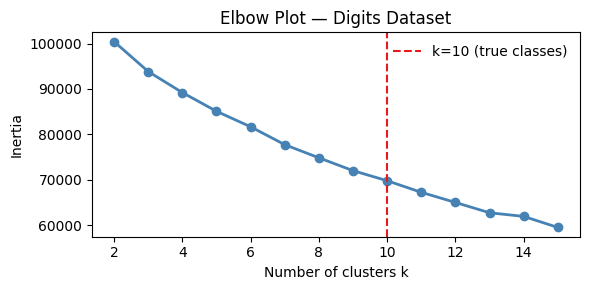

In [12]:
# ── §5 Mini-example: elbow plot (inertia vs k) ──────────────────────────────

inertias = []
k_values = range(2, 16)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled5)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(k_values), inertias, marker='o', color='steelblue', lw=2)
ax.axvline(10, color='#e41a1c', linestyle='--', label='k=10 (true classes)')
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Plot — Digits Dataset')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
# The bend near k=10 suggests 10 natural clusters — matching the 10 digit classes

### Exercise 5

Run `KMeans` with `n_clusters ∈ {5, 10, 15}` on `X_scaled5`.
Print the inertia for each. Does inertia always decrease as k increases? Why?

In [ ]:
# ── §5 Exercise 5 — template ─────────────────────────────────────────────────

for k in [5, 10, 15]:
    km_ex = KMeans(n_clusters=..., random_state=42, n_init=10)   # ← k
    km_ex.fit(X_scaled5)
    print(f'k={k:2d}  inertia={km_ex.inertia_:.1f}')
# After running: does inertia go up or down as k increases?
# Why is lower inertia not always better?

In [ ]:
# ── §5 SOLUTION ──────────────────────────────────────────────────────────────

for k in [5, 10, 15]:
    km_ex = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_ex.fit(X_scaled5)
    print(f'k={k:2d}  inertia={km_ex.inertia_:.1f}')
# Inertia always decreases with more clusters: more centroids → shorter distances.
# Lowest inertia would be k=n_samples (every point is its own cluster) — useless.
# That is why NMI/ARI (which compare to ground truth) matter more than inertia.

---
## §6 `PCA` — Dimensionality Reduction

### Two separate uses of PCA in your thesis

| Use | `n_components` | Purpose |
|-----|---------------|---------|
| KMeans input | 10–20 | Removes noise, speeds up clustering, improves NMI/ARI |
| Scatter plot | 2 | Projects embeddings to 2D for visualisation only |

**These should be two separate PCA fits — never use PCA(2) as KMeans input.**

### Why 2D ≠ best clustering input

`PCA(2)` discards 62 of 64 components from the digits dataset.
Throwing away that much signal degrades clustering.
`PCA(10)` keeps far more structure while still reducing noise.

### Thesis connection

The scatter plot in `matplotlib.ipynb` §2 used pre-made 2D data.
In your thesis, `PCA(n_components=2).fit_transform(X)` produces that data from real embeddings.

X_scaled6 shape: (1797, 64)
X_pca10   shape: (1797, 10)
Variance explained by 10 components: 0.589

X_pca2 shape: (1797, 2)
Variance explained by  2 components: 0.216



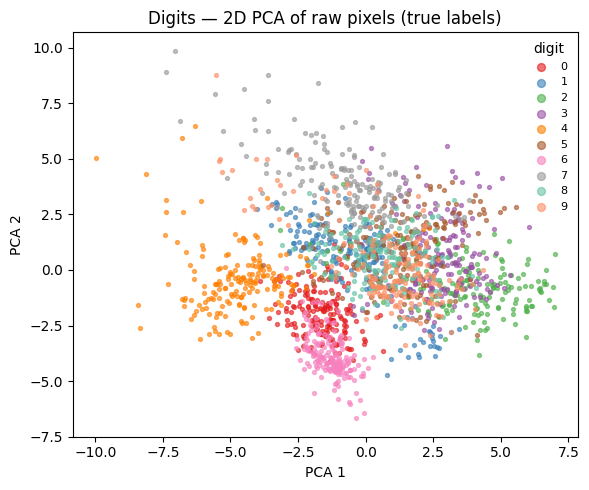

In [13]:
# ── §6 Worked example ────────────────────────────────────────────────────────

X_scaled6 = StandardScaler().fit_transform(X_raw)

# PCA(10) — for KMeans input
pca10 = PCA(n_components=10, random_state=42)
X_pca10 = pca10.fit_transform(X_scaled6)
print('X_scaled6 shape:', X_scaled6.shape)   # (1797, 64)
print('X_pca10   shape:', X_pca10.shape)     # (1797, 10)
print('Variance explained by 10 components:',
      pca10.explained_variance_ratio_.sum().round(3))
print()

# PCA(2) — for scatter plots only
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled6)
print('X_pca2 shape:', X_pca2.shape)   # (1797, 2)
print('Variance explained by  2 components:',
      pca2.explained_variance_ratio_.sum().round(3))
print()

# Scatter plot coloured by true labels — reusing matplotlib.ipynb §2 loop pattern
fig, ax = plt.subplots(figsize=(6, 5))
for k in range(10):
    mask = y_true == k
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               color=COLORS_10[k], s=8, alpha=0.6, label=str(k))
ax.set_title('Digits — 2D PCA of raw pixels (true labels)')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.legend(title='digit', frameon=False, markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
# ── §6 Mini-example: how many components capture 90% of variance? ────────────

pca_full = PCA(random_state=42)   # no n_components → keep all 64
pca_full.fit(X_scaled6)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.searchsorted(cumvar, 0.90)) + 1   # components needed for 90%
print(f'{n_90} components explain 90% of variance (out of 64 total)')
print(f'10 components explain {cumvar[9]:.1%}')
print(f' 2 components explain {cumvar[1]:.1%}')
# Low 2D coverage explains why the scatter plot doesn't show perfect separation

31 components explain 90% of variance (out of 64 total)
10 components explain 58.9%
 2 components explain 21.6%


### Exercise 6

1. Apply `PCA(10)` followed by `KMeans(n_clusters=10)` on `X_scaled6`.
2. Apply `PCA(2)` separately for visualisation (fit on `X_scaled6`, not on the PCA(10) output).
3. Plot the 2D projection coloured by **KMeans predicted labels** (not ground truth).
4. Compare visually to the worked-example plot (true labels). Do the colour patches align?

In [ ]:
# ── §6 Exercise 6 — template ─────────────────────────────────────────────────

# 1. PCA(10) + KMeans
X_pca10_ex = PCA(n_components=..., random_state=42).fit_transform(X_scaled6)   # ← 10
km6 = KMeans(n_clusters=10, random_state=42, n_init=10)
km6.fit(X_pca10_ex)
km_labels = km6.labels_

# 2. PCA(2) for visualisation — separate fit on X_scaled6
X_pca2_ex = PCA(n_components=..., random_state=42).fit_transform(X_scaled6)    # ← 2

# 3. Scatter plot coloured by km_labels
fig, ax = plt.subplots(figsize=(6, 5))
for k in range(10):
    mask = km_labels == k
    ax.scatter(X_pca2_ex[mask, 0], X_pca2_ex[mask, 1],
               color=COLORS_10[k], s=8, alpha=0.6, label=str(k))
ax.set_title('Digits — 2D PCA coloured by KMeans labels')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.legend(title='cluster', frameon=False, markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()
# Patches should mostly align with the true-label plot,
# but colours may be swapped — KMeans label numbering is arbitrary.

In [ ]:
# ── §6 SOLUTION ──────────────────────────────────────────────────────────────

X_pca10_ex = PCA(n_components=10, random_state=42).fit_transform(X_scaled6)
km6 = KMeans(n_clusters=10, random_state=42, n_init=10)
km6.fit(X_pca10_ex)
km_labels = km6.labels_

X_pca2_ex = PCA(n_components=2, random_state=42).fit_transform(X_scaled6)

fig, ax = plt.subplots(figsize=(6, 5))
for k in range(10):
    mask = km_labels == k
    ax.scatter(X_pca2_ex[mask, 0], X_pca2_ex[mask, 1],
               color=COLORS_10[k], s=8, alpha=0.6, label=str(k))
ax.set_title('Digits — 2D PCA coloured by KMeans labels')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.legend(title='cluster', frameon=False, markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

---
## §7 Clustering Metrics — NMI, ARI, Silhouette

### The three metrics in your thesis

You know these conceptually from your Data Mining course. Here you learn the sklearn API.

| Metric | Needs ground truth? | Range | `0` means | `1` means |
|--------|-------------------|-------|-----------|-----------|
| NMI | Yes | [0, 1] | random assignment | perfect recovery |
| ARI | Yes | [−1, 1] | random assignment | perfect recovery |
| Silhouette | **No** | [−1, 1] | overlapping clusters | perfectly separated |

### When to use which

**NMI and ARI** are your primary metrics — use them on all benchmark datasets with known labels.
**Silhouette** is for ablation studies and datasets without labels (measures cluster cohesion).

### API

```python
nmi = normalized_mutual_info_score(y_true, y_pred)   # both integer arrays
ari = adjusted_rand_score(y_true, y_pred)
sil = silhouette_score(X, y_pred)                    # also needs the feature matrix
```

In [ ]:
# ── §7 Worked example ────────────────────────────────────────────────────────

# Full pipeline: scale → PCA(10) → KMeans → evaluate
X_scaled7 = StandardScaler().fit_transform(X_raw)
X_pca10_7 = PCA(n_components=10, random_state=42).fit_transform(X_scaled7)

km7 = KMeans(n_clusters=10, random_state=42, n_init=10)
km7.fit(X_pca10_7)
y_pred7 = km7.labels_

nmi7 = normalized_mutual_info_score(y_true, y_pred7)
ari7 = adjusted_rand_score(y_true, y_pred7)
sil7 = silhouette_score(X_pca10_7, y_pred7)

print(f'NMI:        {nmi7:.4f}   (0=random, 1=perfect)')
print(f'ARI:        {ari7:.4f}   (0=random, 1=perfect)')
print(f'Silhouette: {sil7:.4f}   (−1=bad, 0=overlapping, 1=well-separated)')

In [ ]:
# ── §7 Mini-example: perfect vs random clustering ───────────────────────────

# Perfect: predicted = true
nmi_p = normalized_mutual_info_score(y_true, y_true)
ari_p = adjusted_rand_score(y_true, y_true)
print(f'Perfect  → NMI={nmi_p:.3f}, ARI={ari_p:.3f}')

# Random: shuffle the true labels
rng7 = np.random.default_rng(0)
y_rand = rng7.permutation(y_true)
nmi_r = normalized_mutual_info_score(y_true, y_rand)
ari_r = adjusted_rand_score(y_true, y_rand)
print(f'Random   → NMI={nmi_r:.3f}, ARI={ari_r:.3f}')
# ARI ≈ 0 for random; NMI is also near 0 — confirms the metrics behave as expected

### Exercise 7

Compare three preprocessing configurations on the full digits dataset:
1. `KMeans` on **raw pixels** (no scaling, no PCA)
2. `KMeans` on **scaled pixels** (StandardScaler only)
3. `KMeans` on **scaled + PCA(10)** (the worked-example configuration)

Print NMI, ARI, Silhouette for each. Which configuration performs best and why?

In [ ]:
# ── §7 Exercise 7 — template ─────────────────────────────────────────────────

configs = {
    'raw':          X_raw,
    'scaled':       StandardScaler().fit_transform(X_raw),
    'scaled+pca10': PCA(n_components=10, random_state=42).fit_transform(
                        StandardScaler().fit_transform(X_raw)),
}

print(f'{"Config":<15} {"NMI":>6} {"ARI":>6} {"Silhouette":>12}')
print('-' * 43)
for name, X_cfg in configs.items():
    km_cfg = KMeans(n_clusters=..., random_state=42, n_init=10)   # ← 10
    km_cfg.fit(X_cfg)
    y_cfg = km_cfg.labels_
    print(f'{name:<15}'
          f' {normalized_mutual_info_score(y_true, y_cfg):>6.3f}'
          f' {adjusted_rand_score(y_true, y_cfg):>6.3f}'
          f' {silhouette_score(X_cfg, y_cfg):>12.3f}')

In [ ]:
# ── §7 SOLUTION ──────────────────────────────────────────────────────────────

configs = {
    'raw':          X_raw,
    'scaled':       StandardScaler().fit_transform(X_raw),
    'scaled+pca10': PCA(n_components=10, random_state=42).fit_transform(
                        StandardScaler().fit_transform(X_raw)),
}

print(f'{"Config":<15} {"NMI":>6} {"ARI":>6} {"Silhouette":>12}')
print('-' * 43)
for name, X_cfg in configs.items():
    km_cfg = KMeans(n_clusters=10, random_state=42, n_init=10)
    km_cfg.fit(X_cfg)
    y_cfg = km_cfg.labels_
    print(f'{name:<15}'
          f' {normalized_mutual_info_score(y_true, y_cfg):>6.3f}'
          f' {adjusted_rand_score(y_true, y_cfg):>6.3f}'
          f' {silhouette_score(X_cfg, y_cfg):>12.3f}')
# scaled+pca10 should give the best NMI/ARI:
# scaling removes magnitude bias; PCA removes noisy dimensions before KMeans.

---
## §8 `fetch_openml` — Loading Thesis Datasets

### Why OpenML?

Your thesis benchmarks augmentation techniques on 3–4 tabular datasets with ground-truth labels.
OpenML provides a standardised repository of such datasets with versioning.

### The loading pattern

```python
dataset = fetch_openml(name='iris', version=1, as_frame=True, parser='auto')
X_df = dataset.data     # pd.DataFrame — inspect with .dtypes, .head()
y    = dataset.target   # pd.Series    — string or integer class labels
```

### Note on internet access

`fetch_openml` downloads on first call, then caches locally.
If you've never fetched a dataset before, you need internet access.

### Candidate datasets for the thesis (Phase A, Week 2)

| Dataset | Samples | Features | Classes |
|---------|---------|---------|---------|
| `pendigits` | 10 992 | 16 | 10 |
| `letter` | 20 000 | 16 | 26 |
| `sensorless` | 58 509 | 48 | 11 |
| `mnist_784` | 70 000 | 784 | 10 |

The `load_and_prep` function you write in this section will work on all of them unchanged.

In [ ]:
# ── §8 Worked example ────────────────────────────────────────────────────────

# Load the iris dataset — small and always available
iris = fetch_openml(name='iris', version=1, as_frame=True, parser='auto')

X_iris = iris.data     # pd.DataFrame: 150 × 4
y_iris = iris.target   # pd.Series: string labels ('Iris-setosa', ...)

print('X_iris shape:', X_iris.shape)
print('X_iris dtypes:')
print(X_iris.dtypes)
print()
print('y_iris value counts:')
print(y_iris.value_counts())
print()
print('X_iris head:')
print(X_iris.head(3))

In [ ]:
# ── §8 Mini-example: encode string labels to integers ───────────────────────
# NMI and ARI need integer arrays — LabelEncoder converts string labels

le = LabelEncoder()
y_iris_int = le.fit_transform(y_iris)   # 'Iris-setosa'→0, 'Iris-versicolor'→1, ...

print('Original:', y_iris[:3].values)
print('Encoded: ', y_iris_int[:3])
print('Classes: ', le.classes_)
# le.inverse_transform([0, 1, 2]) turns integers back to strings if needed

### Exercise 8

Write a reusable function `load_and_prep(name, version=1)` that:
1. Fetches the dataset from OpenML
2. Encodes the target as integers with `LabelEncoder`
3. Applies `ColumnTransformer` (StandardScaler for numerical, OneHotEncoder for categorical)
4. Returns `(X_prep, y)` — both as numpy arrays

Test it on `'iris'` and print shapes and unique labels.

In [ ]:
# ── §8 Exercise 8 — template ─────────────────────────────────────────────────

def load_and_prep(name, version=1):
    """Fetch from OpenML, encode labels, preprocess features. Returns (X_prep, y)."""
    dataset = fetch_openml(name=name, version=version, as_frame=True, parser='auto')
    X_df     = dataset.data
    y_series = dataset.target

    y = LabelEncoder().fit_transform(y_series)   # string labels → integers

    num_c = X_df.select_dtypes(include='number').columns.tolist()
    cat_c = X_df.select_dtypes(include=['object', 'category']).columns.tolist()

    steps = [('num', StandardScaler(), num_c)]
    if cat_c:   # only add OHE if there are categorical columns
        steps.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_c))

    X_prep = ColumnTransformer(steps).fit_transform(X_df)
    return X_prep, y


X_iris_prep, y_iris_prep = load_and_prep(...)   # ← 'iris'
print('iris — X shape:', X_iris_prep.shape)
print('iris — y shape:', y_iris_prep.shape)
print('iris — unique labels:', np.unique(y_iris_prep))

In [ ]:
# ── §8 SOLUTION ──────────────────────────────────────────────────────────────

def load_and_prep(name, version=1):
    """Fetch from OpenML, encode labels, preprocess features. Returns (X_prep, y)."""
    dataset  = fetch_openml(name=name, version=version, as_frame=True, parser='auto')
    X_df     = dataset.data
    y_series = dataset.target

    y = LabelEncoder().fit_transform(y_series)

    num_c = X_df.select_dtypes(include='number').columns.tolist()
    cat_c = X_df.select_dtypes(include=['object', 'category']).columns.tolist()

    steps = [('num', StandardScaler(), num_c)]
    if cat_c:
        steps.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_c))

    X_prep = ColumnTransformer(steps).fit_transform(X_df)
    return X_prep, y


X_iris_prep, y_iris_prep = load_and_prep('iris')
print('iris — X shape:', X_iris_prep.shape)   # (150, 4)
print('iris — y shape:', y_iris_prep.shape)   # (150,)
print('iris — unique labels:', np.unique(y_iris_prep))   # [0, 1, 2]

---
## ★ Capstone: End-to-End Pipeline on Digits

### What you build here

The full thesis pipeline — minus the MLP encoder (that is PyTorch, covered next).
This is structurally identical to what Week 3 of the official thesis work produces.

```
load_digits()
  → StandardScaler
  → PCA(10)  ← KMeans input
  → PCA(2)   ← scatter plot (separate fit)
  → KMeans(n_clusters=10)
  → NMI, ARI, Silhouette
  → scatter plot coloured by predicted label
  → save as 'results_digits.pdf'
```

**Part 1 (required):** implement the pipeline and print the three metrics.

**Part 2 (exercise):** run with `n_clusters ∈ {5, 10, 15}` and print a results table.

In [ ]:
# ── Capstone Part 1 — YOUR CODE ──────────────────────────────────────────────

# Step 1: scale
X_sc = StandardScaler().fit_transform(X_raw)

# Step 2a: PCA(10) → KMeans input
X_10 = PCA(n_components=10, random_state=42).fit_transform(X_sc)

# Step 2b: PCA(2) → scatter plot (separate fit on X_sc, not on X_10)
X_2  = PCA(n_components=2, random_state=42).fit_transform(X_sc)

# Step 3: KMeans
km_cap = KMeans(n_clusters=10, random_state=42, n_init=10)
km_cap.fit(X_10)
y_pred = km_cap.labels_

# Step 4: metrics
nmi_c = normalized_mutual_info_score(y_true, y_pred)
ari_c = adjusted_rand_score(y_true, y_pred)
sil_c = silhouette_score(X_10, y_pred)
print(f'NMI={nmi_c:.4f}  ARI={ari_c:.4f}  Silhouette={sil_c:.4f}')

# Step 5: scatter plot — matplotlib.ipynb §2 loop pattern
fig, ax = plt.subplots(figsize=(6, 5))
for k in range(10):
    mask = y_pred == k
    ax.scatter(X_2[mask, 0], X_2[mask, 1],
               color=COLORS_10[k], s=10, alpha=0.6, label=str(k))
ax.set_title(f'Digits — KMeans k=10  NMI={nmi_c:.3f}  ARI={ari_c:.3f}', fontsize=10)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.legend(title='cluster', frameon=False, markerscale=2, fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('results_digits.pdf', bbox_inches='tight')   # PDF for LaTeX inclusion
print('Saved: results_digits.pdf')
plt.show()

In [ ]:
# ── Capstone Part 2 — Exercise: vary n_clusters ──────────────────────────────

print(f'{"k":>3} | {"NMI":>6} | {"ARI":>6} | {"Silhouette":>12}')
print('-' * 36)
for k in [5, 10, 15]:
    km_p2 = KMeans(n_clusters=..., random_state=42, n_init=10)   # ← k
    km_p2.fit(X_10)   # X_10 is the PCA(10) output from Part 1
    y_p2 = km_p2.labels_
    print(f'{k:>3} |'
          f' {normalized_mutual_info_score(y_true, y_p2):>6.3f} |'
          f' {adjusted_rand_score(y_true, y_p2):>6.3f} |'
          f' {silhouette_score(X_10, y_p2):>12.3f}')

In [ ]:
# ── Capstone Part 2 — SOLUTION ───────────────────────────────────────────────

print(f'{"k":>3} | {"NMI":>6} | {"ARI":>6} | {"Silhouette":>12}')
print('-' * 36)
for k in [5, 10, 15]:
    km_p2 = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_p2.fit(X_10)
    y_p2 = km_p2.labels_
    print(f'{k:>3} |'
          f' {normalized_mutual_info_score(y_true, y_p2):>6.3f} |'
          f' {adjusted_rand_score(y_true, y_p2):>6.3f} |'
          f' {silhouette_score(X_10, y_p2):>12.3f}')
# k=10 should have the best NMI/ARI: it matches the true number of digit classes.

---
## Quick Reference Card

| API call | What it does |
|----------|-------------|
| `StandardScaler().fit_transform(X_train)` | Scale train: learn mean/std + apply |
| `scaler.transform(X_test)` | Scale test using training statistics |
| `scaler.mean_` / `scaler.scale_` | Learned mean and std per feature |
| `OneHotEncoder(sparse_output=False, handle_unknown='ignore')` | Encode categoricals to binary vectors |
| `enc.get_feature_names_out()` | Names of the OHE output columns |
| `ColumnTransformer([('name', transformer, cols), ...])` | Apply different transformers to different column groups |
| `preprocess.get_feature_names_out()` | Names of all output columns |
| `Pipeline(steps=[('name', step), ...])` | Chain steps; one `.fit()` / `.predict()` call |
| `pipe.named_steps['name']` | Access a specific step inside a fitted pipeline |
| `KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)` | Cluster X into k groups |
| `km.labels_` | Cluster assignment per sample after fit, shape `(n_samples,)` |
| `km.cluster_centers_` | Centroid coordinates, shape `(n_clusters, n_features)` |
| `km.inertia_` | Sum of squared distances to nearest centroid |
| `PCA(n_components=n).fit_transform(X)` | Project X to n dimensions |
| `pca.explained_variance_ratio_` | Fraction of variance captured per component |
| `np.cumsum(pca.explained_variance_ratio_)` | Cumulative explained variance |
| `normalized_mutual_info_score(y_true, y_pred)` | NMI: 0 = random, 1 = perfect |
| `adjusted_rand_score(y_true, y_pred)` | ARI: 0 = random, 1 = perfect |
| `silhouette_score(X, labels)` | Cluster quality without ground truth |
| `fetch_openml(name='...', version=1, as_frame=True, parser='auto')` | Load dataset from OpenML |
| `LabelEncoder().fit_transform(y_str)` | Encode string labels to integers |